#### Size Sweep

In [4]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

project_root = Path.cwd().parents[2]
sys.path.insert(0, str(project_root))

torch.set_default_dtype(torch.float64) 

# Functions needed for data generation
from scripts.shape_uncertainty.simulated_data.data_generator import WilkersonDGP
from scripts.shape_uncertainty.simulated_data.data_generator import generate_simulated_dataset
from scripts.shape_uncertainty.spline_basis.bspline_basis import build_knot_dictionary

# Functions needed to run MeanOnlyModel
from scripts.shape_uncertainty.model.model import MeanOnlyModel
from scripts.shape_uncertainty.model.model_training import Tuner
from scripts.shape_uncertainty.experiments.utilities import save_run, load_run

# Functions needed for shape extraction
from scripts.shape_uncertainty.model.model_inference import InferenceEngine
from scripts.shape_uncertainty.model.model_evaluation import ModelEvaluator
from scripts.shape_uncertainty.simulated_data.shape_ground_truth import get_analytic_shape_summary
from scripts.shape_uncertainty.shape_extraction.shape_distance import (
    exact_shape_sequence_match, shape_summary_distance,
    mean_shape_sequence_match, mean_shape_summary_distance,
)

# Helpers needed for plotting
from scripts.shape_uncertainty.experiments.plot_helpers import plot_individual_diagnostic

In [5]:
# Data-generating process
T = 1.0
ALPHA_G, ALPHA_D = 0.0, 0.0 # 0 = no unobserved heterogeneity
HYPERPARAMS = {"g0": 2.0, "d0": 180.0, "rho0": 10.0,
               "alpha_g": ALPHA_G, "alpha_d": ALPHA_D}

# Observation design 
NR_OBS = 20 # observations per individual
SIGMA = 0.0 # measurement-noise std
REGULAR = True
SEED = 42

# Spline basis
NR_INTERIOR_KNOTS = 5 # B = K + 4 = 9, matches TimeView

# Wiggle regulariser
LAMBDA_MEAN = 0 # 1e-05

# Dataset sizes
D_VALUES = [500, 1000, 2000, 5000, 10000, 20000]
D_TRAIN_MAX, D_VAL, D_TEST = max(D_VALUES), 1000, 1000
D_TOTAL = D_TRAIN_MAX + D_VAL + D_TEST


# Pruned shape extraction
UPSILON_1_REL, UPSILON_2_REL = 0.0, 0.0
ZETA_REL, UPSILON_PRUNE_REL, DO_PRUNE = 1e-6, 0.025, True

In [6]:
# Specify the configuration for the data generating process 
dgp = WilkersonDGP(
        T=T, 
        hyperparams=HYPERPARAMS,
        ranges=None, # set to default
)
# Create a dataset from the specified DGP 
dataset = generate_simulated_dataset(
                dgp, 
                D=D_TOTAL,
                N=NR_OBS, 
                sigma=SIGMA, 
                regular=REGULAR,
                include_endpoints=True,
                seed=SEED
)

# Split the dataset into test, validation and training sets 
test, val, train_pool = dataset.split_test_val_train(D_train=D_TRAIN_MAX, D_val=D_VAL, D_test=D_TEST)


In [7]:
# Built a dictionary with the key spline objects
knot_objects = build_knot_dictionary(nr_interior_knots=NR_INTERIOR_KNOTS, T=T)

In [13]:
# Search for the best hyperparameter configuration ONCE at the largest training set size
tuner = Tuner(
    train_dataset=train_pool,
    val_dataset=val,
    basis_functions=knot_objects["basis_functions"],
    Omega=knot_objects["Omega"],
    nr_basis=knot_objects["nr_basis"],
    lambda_mean=LAMBDA_MEAN,
    lambda_re=0.0,
    nr_epochs=200,
    model_cls=MeanOnlyModel,
    model_kwargs={},
    patience=10,
)
reference = tuner.run(nr_trials=100)
fixed_params = reference["best_params"]
print("frozen architecture:", fixed_params)

[I 2026-07-22 03:34:56,222] A new study created in memory with name: no-name-14136abe-2972-4a33-b5bc-a5b9c8d4c328
[I 2026-07-22 03:35:04,855] Trial 0 finished with value: 0.590591927017019 and parameters: {'hidden_0': 50, 'hidden_1': 100, 'hidden_2': 62, 'activation': 'leaky_relu', 'dropout': 0.22824460027993804, 'lr': 0.0013138656765707155, 'batch_size': 128, 'weight_decay': 0.002949132139322547}. Best is trial 0 with value: 0.590591927017019.
[I 2026-07-22 03:35:20,343] Trial 1 finished with value: 0.5814722439521223 and parameters: {'hidden_0': 121, 'hidden_1': 82, 'hidden_2': 28, 'activation': 'elu', 'dropout': 0.23111943900973236, 'lr': 0.0035433132509208013, 'batch_size': 128, 'weight_decay': 0.00024056498021706834}. Best is trial 1 with value: 0.5814722439521223.
[I 2026-07-22 03:35:29,916] Trial 2 finished with value: 0.816725302427499 and parameters: {'hidden_0': 103, 'hidden_1': 116, 'hidden_2': 101, 'activation': 'leaky_relu', 'dropout': 0.31397636909435717, 'lr': 0.01711826

frozen architecture: {'hidden_sizes': [128, 109, 99], 'activation': 'elu', 'dropout': 0.0009546025583504809, 'lr': 0.0008019258205080772, 'batch_size': 128, 'weight_decay': 4.6414269384889754e-06}


In [14]:
# Train models on training sets of each size at the frozen architecture
knot_config = {"nr_interior_knots": NR_INTERIOR_KNOTS, "T": T}

for d in D_VALUES:
    train_d = train_pool.take_first_d_individuals(d)
    tuner = Tuner(
        train_dataset=train_d, 
        val_dataset=val,
        basis_functions=knot_objects["basis_functions"], 
        Omega=knot_objects["Omega"],
        nr_basis=knot_objects["nr_basis"], 
        lambda_mean=LAMBDA_MEAN, 
        lambda_re=0.0,
        nr_epochs=200, 
        patience=10, 
        model_cls=MeanOnlyModel, 
        model_kwargs={},
    )
    result = tuner.train_fixed_configuration(fixed_params)
    save_run(result, knot_config, generate_config=train_d.gen_config,
             lambda_mean=LAMBDA_MEAN, path=f"trained_models/dsweep_lambda_{LAMBDA_MEAN}/dsweep_D_{d}")
    print(f"D={d:>6}  val={result['best_value']:.4f}")

D=   500  val=0.5766
D=  1000  val=0.5753
D=  2000  val=0.5747
D=  5000  val=0.5749
D= 10000  val=0.5744
D= 20000  val=0.5742


In [8]:
# Evaluate each saved model on the FIXED test set
def make_engine(loaded, zeta, uprune, prune):
    ko = loaded["knot_objects"]
    eng = InferenceEngine()
    eng.populate_attributes(
        model=loaded["model"], 
        normaliser=loaded["normaliser"],
        basis_functions=ko["basis_functions"], 
        C=ko["C"], 
        breakpoints=ko["breakpoints"],
        zeta_rel=zeta, 
        upsilon_rel_1=0.0, 
        upsilon_rel_2=0.0,
        upsilon_rel_prune=uprune, 
        do_prune=prune,
    )
    return eng

def score(engine, dataset, uprune, prune):
    predicted = [engine.predict_mean_shape_summary(x) for x in dataset.individual_covariates()]
    true = get_analytic_shape_summary(dataset, 0.0, 0.0, uprune, prune)
    return (mean_shape_sequence_match(predicted, true),
            mean_shape_summary_distance(predicted, true, dataset.T))

rows = []
for d in D_VALUES:
    loaded = load_run(path=f"trained_models/dsweep_lambda_{LAMBDA_MEAN}/dsweep_D_{d}", model_cls=MeanOnlyModel)
    naive_engine  = make_engine(loaded, 0.0,      0.0,              False)
    pruned_engine = make_engine(loaded, ZETA_REL, UPSILON_PRUNE_REL, True)

    r2 = ModelEvaluator(naive_engine, test).compute_value_space_accuracy()["r2"]
    rmse = ModelEvaluator(naive_engine, test).compute_value_space_accuracy()["rmse"]
    acc_n, dist_n = score(naive_engine,  test, 0.0,              False)
    acc_p, dist_p = score(pruned_engine, test, UPSILON_PRUNE_REL, True)

    rows.append({"D": d, "value_r2": r2, "value_rmse": rmse,
                 "acc_naive": acc_n, "dist_naive": dist_n,
                 "acc_pruned": acc_p, "dist_pruned": dist_p})

df = pd.DataFrame(rows)
display(df)
print(df.to_latex(index=False, float_format="%.3f"))


,D,value_r2,value_rmse,acc_naive,dist_naive,acc_pruned,dist_pruned
0,500,0.996418,0.033447,0.022,0.152904,0.491,0.083060
1,1000,0.998560,0.021210,0.064,0.106705,0.715,0.040541
2,2000,0.998669,0.020390,0.052,0.099762,0.650,0.040557
3,5000,0.998999,0.017681,0.110,0.076336,0.849,0.020892
4,10000,0.999379,0.013928,0.173,0.055535,0.919,0.012975
5,20000,0.999655,0.010385,0.257,0.039846,0.954,0.008059


\begin{tabular}{rrrrrrr}
\toprule
D & value_r2 & value_rmse & acc_naive & dist_naive & acc_pruned & dist_pruned \\
\midrule
500 & 0.996 & 0.033 & 0.022 & 0.153 & 0.491 & 0.083 \\
1000 & 0.999 & 0.021 & 0.064 & 0.107 & 0.715 & 0.041 \\
2000 & 0.999 & 0.020 & 0.052 & 0.100 & 0.650 & 0.041 \\
5000 & 0.999 & 0.018 & 0.110 & 0.076 & 0.849 & 0.021 \\
10000 & 0.999 & 0.014 & 0.173 & 0.056 & 0.919 & 0.013 \\
20000 & 1.000 & 0.010 & 0.257 & 0.040 & 0.954 & 0.008 \\
\bottomrule
\end{tabular}



,D,estimation,bias,total,bound,acc_estimation,acc_bias,acc_total
0,500,0.083060,0.006075,0.085977,0.089135,0.491,0.889,0.458
1,1000,0.040541,0.006075,0.044181,0.046616,0.715,0.889,0.667
2,2000,0.040557,0.006075,0.044359,0.046632,0.650,0.889,0.586
3,5000,0.020892,0.006075,0.025911,0.026967,0.849,0.889,0.760
4,10000,0.012975,0.006075,0.016783,0.019050,0.919,0.889,0.843
5,20000,0.008059,0.006075,0.012328,0.014134,0.954,0.889,0.869


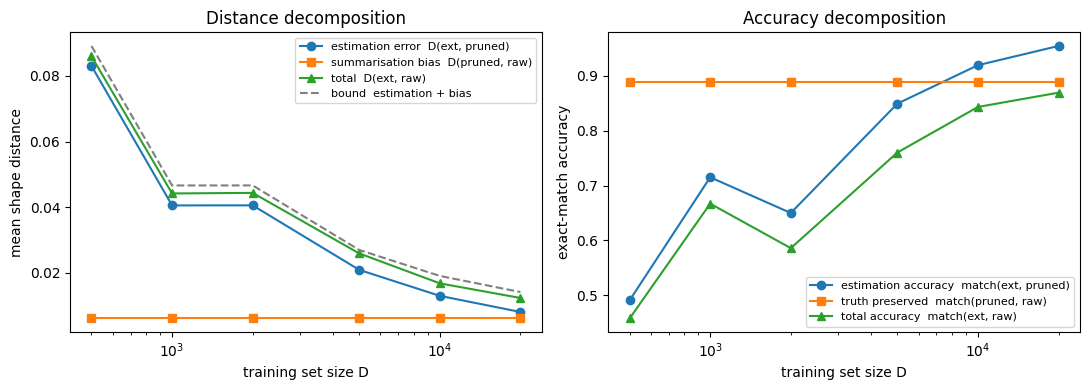

In [10]:
from scripts.shape_uncertainty.simulated_data.shape_ground_truth import get_analytic_shape_summary
from scripts.shape_uncertainty.shape_extraction.shape_distance import mean_shape_summary_distance

# raw truth = analytic shape with NO pruning (the exact mathematical shape)
raw_truth = get_analytic_shape_summary(test, UPSILON_1_REL, UPSILON_2_REL, 0.0, False)
# pruned truth = analytic shape at the SAME settings as the extractor
pruned_truth = get_analytic_shape_summary(test, UPSILON_1_REL, UPSILON_2_REL,
                                          UPSILON_PRUNE_REL, True)

decomp = []
for d in D_VALUES:
    loaded = load_run(path=f"trained_models/dsweep_lambda_{LAMBDA_MEAN}/dsweep_D_{d}", model_cls=MeanOnlyModel)
    engine = make_engine(loaded, ZETA_REL, UPSILON_PRUNE_REL, True)   # pruned extractor
    predicted = [engine.predict_mean_shape_summary(x) for x in test.individual_covariates()]

    est   = mean_shape_summary_distance(predicted,    pruned_truth, test.T)  # estimation error
    bias  = mean_shape_summary_distance(pruned_truth, raw_truth,    test.T)  # summarisation bias
    total = mean_shape_summary_distance(predicted,    raw_truth,    test.T)  # total discrepancy

    acc_est   = mean_shape_sequence_match(predicted,    pruned_truth)
    acc_bias  = mean_shape_sequence_match(pruned_truth, raw_truth)
    acc_total = mean_shape_sequence_match(predicted,    raw_truth)

    decomp.append({"D": d, "estimation": est, "bias": bias, "total": total,
                   "bound": est + bias,
                   "acc_estimation": acc_est, "acc_bias": acc_bias, "acc_total": acc_total})

df_decomp = pd.DataFrame(decomp)
display(df_decomp)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)

ax = axes[0]
ax.plot(df_decomp["D"], df_decomp["estimation"], marker="o", label="estimation error  D(ext, pruned)")
ax.plot(df_decomp["D"], df_decomp["bias"],       marker="s", label="summarisation bias  D(pruned, raw)")
ax.plot(df_decomp["D"], df_decomp["total"],      marker="^", label="total  D(ext, raw)")
ax.plot(df_decomp["D"], df_decomp["bound"], linestyle="--", color="grey", label="bound  estimation + bias")
ax.set_xscale("log"); ax.set_xlabel("training set size D"); ax.set_ylabel("mean shape distance")
ax.set_title("Distance decomposition"); ax.legend(fontsize=8)

ax = axes[1]
ax.plot(df_decomp["D"], df_decomp["acc_estimation"], marker="o", label="estimation accuracy  match(ext, pruned)")
ax.plot(df_decomp["D"], df_decomp["acc_bias"],       marker="s", label="truth preserved  match(pruned, raw)")
ax.plot(df_decomp["D"], df_decomp["acc_total"],      marker="^", label="total accuracy  match(ext, raw)")
ax.set_xscale("log"); ax.set_xlabel("training set size D"); ax.set_ylabel("exact-match accuracy")
ax.set_title("Accuracy decomposition"); ax.legend(fontsize=8)

fig.tight_layout()
plt.show()


Each curve compares shape summaries across three different combinations of (analytic vs. numeric extractor) × (pruned vs. unpruned ground truth), evaluated on the fixed test set at a fixed pruning threshold (υ_prune = 0.025) as training size D grows. 
- Estimation error is D(predicted, pruned_truth) — the distance between the shape sequence the numeric extractor reads off the fitted model and the shape sequence the analytic extractor reads off the exact DGP curve, both under the same pruning rule; it isolates how far the fitted curve is from the true curve, holding the pruning convention fixed. 
- Summarisation bias is D(pruned_truth, raw_truth) — the distance between the exact DGP curve's shape under pruning and its shape with no pruning at all; it isolates how much the pruning convention itself distorts the true shape, independently of any model fit (it never touches predicted, which is why it's flat in D). 
- Total is D(predicted, raw_truth) — the distance actually realized between what the pipeline reports and the true mathematical shape, i.e. the number that matters in practice, since it reflects both effects at once. Because shape-summary distance is a proper (triangle-inequality-respecting) metric, total can never exceed estimation + bias; that sum is plotted as a separate dashed bound line, so the gap between total and bound shows how much the two error sources compound versus partially cancel, rather than being read off the total curve itself.